In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset directly from seaborn
df = sns.load_dataset('titanic')

# Inspect data
print("--- First 5 Rows ---")
print(df.head())

print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

--- First 5 Rows ---
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

--- Missing Values Per Column ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class      

In [2]:
# Create Age Buckets
df['age_bucket'] = pd.cut(df['age'], bins=[0, 18, 60, 100], labels=['Child', 'Adult', 'Senior'])

# Calculate Survival Rates
print("--- Survival Rate by Sex ---")
print(df.groupby('sex')['survived'].mean())

print("\n--- Survival Rate by Class ---")
print(df.groupby('class')['survived'].mean())

print("\n--- Survival Rate by Age Bucket ---")
print(df.groupby('age_bucket')['survived'].mean())

--- Survival Rate by Sex ---
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

--- Survival Rate by Class ---
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

--- Survival Rate by Age Bucket ---
age_bucket
Child     0.503597
Adult     0.388788
Senior    0.227273
Name: survived, dtype: float64


/tmp/ipykernel_1092/3765659597.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('class')['survived'].mean())
/tmp/ipykernel_1092/3765659597.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('age_bucket')['survived'].mean())


/tmp/ipykernel_1092/2792110360.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, ax=axes[0], palette='Blues_d')
/tmp/ipykernel_1092/2792110360.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='survived', data=df, ax=axes[1], palette='Greens_d')
/tmp/ipykernel_1092/2792110360.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='age', data=df, ax=axes[2], palette='Set2')


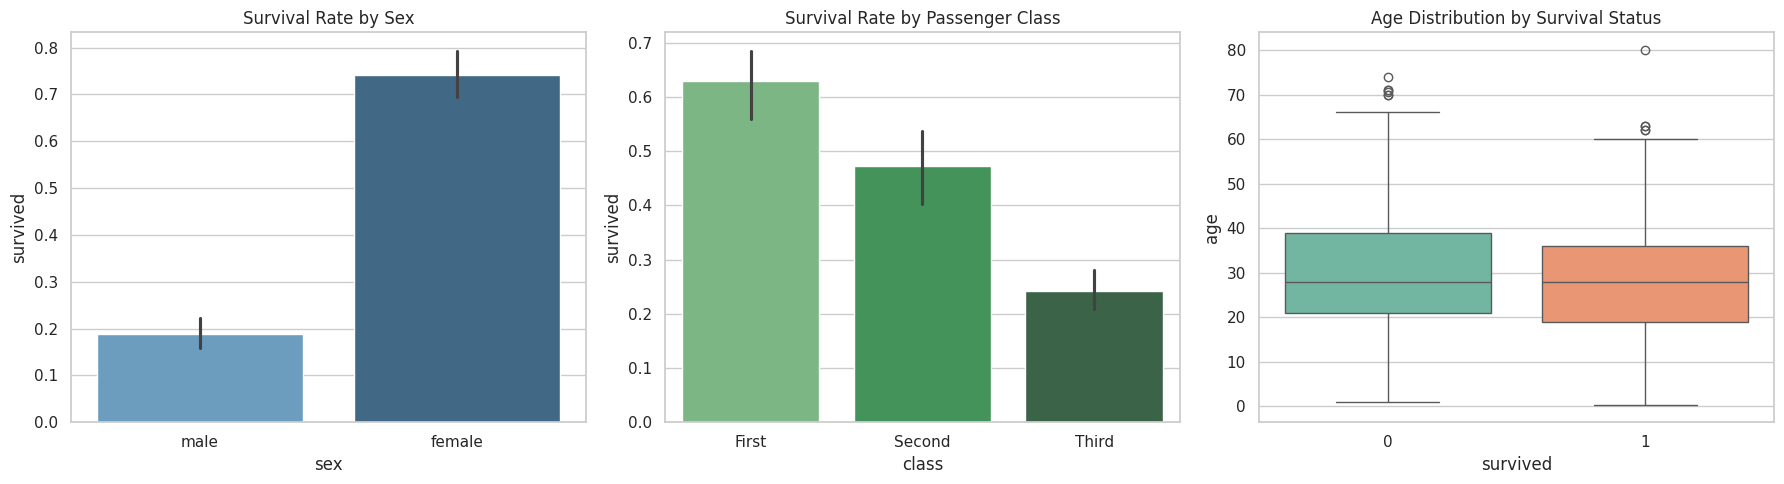

In [3]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Survival Rate by Sex
sns.barplot(x='sex', y='survived', data=df, ax=axes[0], palette='Blues_d')
axes[0].set_title('Survival Rate by Sex')

# Plot 2: Survival Rate by Passenger Class
sns.barplot(x='class', y='survived', data=df, ax=axes[1], palette='Greens_d')
axes[1].set_title('Survival Rate by Passenger Class')

# Plot 3: Age Distribution by Survival Status
sns.boxplot(x='survived', y='age', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Age Distribution by Survival Status')

plt.tight_layout()
plt.show()

### Key Insights Report
* **Gender Disparity:** Women had a significantly higher survival rate (~74%) compared to men (~19%).
* **Socioeconomic Factor:** First-class passengers achieved the highest survival rate (~63%), while third-class passengers had the lowest (~24%).
* **Age Distribution:** Children had a higher likelihood of survival compared to adults and seniors.